In [31]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)

from gerrychain.proposals import recom, propose_random_flip

from gerrychain.tree import recursive_tree_part, recursive_seed_part

from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias

from gerrychain.updaters import cut_edges

from gerrychain.tree import bipartition_tree, find_balanced_edge_cuts_memoization


from collections import Counter
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx


In [26]:
df = gpd.read_file("../NC_Processed/output/NC_Processed_Precincts_ALARM.shp")
graph = Graph.from_geodataframe(df)

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:457: UserWarning: NA values found in column muni!
  warnings.warn("NA values found in column {}!".format(column))
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:457: UserWarning: NA values found in column arv_18!
  warnings.warn("NA values found in column {}!".format(column))
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:457: UserWarning: NA values found in column adv_18!
  warnings.warn("NA values found in column {}!".format(column))


In [27]:
df.columns

Index(['GEOID', 'state', 'county', 'muni', 'cnty_mn', 'cd_2010', 'vtd', 'pop',
       'pop_hsp', 'pop_wht', 'pp_blck', 'pop_ain', 'pop_asn', 'pop_nhp',
       'pop_thr', 'pop_two', 'vap', 'vap_hsp', 'vap_wht', 'vp_blck', 'vap_ain',
       'vap_asn', 'vap_nhp', 'vap_thr', 'vap_two', 'pr_16_r_', 'pr_16_d_',
       'uss_16_r_', 'uss_16_d_', 'gv_16_r_', 'gv_16_d_', 'atg_16_r_',
       'atg_16_d_', 'ss_16_r_', 'ss_16_d_', 'pr_20_r_', 'pr_20_d_',
       'uss_20_r_', 'uss_20_d_', 'gv_20_r_', 'gv_20_d_', 'atg_20_r_',
       'atg_20_d_', 'ss_20_r_', 'ss_20_d_', 'arv_16', 'adv_16', 'arv_18',
       'adv_18', 'arv_20', 'adv_20', 'nrv', 'ndv', 'are_lnd', 'are_wtr',
       'cd_2020', 'psd_cnt', 'CON', 'SLDU', 'SLDL', 'C_X', 'C_Y', 'geometry'],
      dtype='object')

C:\Users\angel\AppData\Local\Temp\ipykernel_21668\4137758829.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  smc_plans = pd.read_csv("./nc_alarm_plans.csv")


(83413.19910039, 976393.9973860099, -15041.935335620003, 333960.31754542)

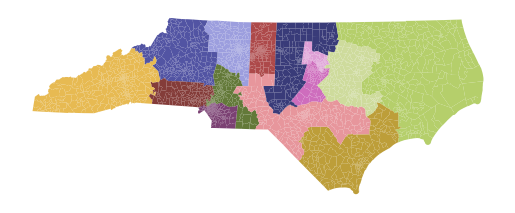

In [28]:


smc_plans = pd.read_csv("./nc_alarm_plans.csv")

smc_plans.rename(columns={"Unnamed: 0":"GEOID"},inplace=True)

smc_plans["GEOID"] = smc_plans["GEOID"].astype("str")

df = df.merge(smc_plans,on="GEOID")

df.plot(column="V123",cmap="tab20b")
plt.axis('off')

In [46]:
def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    current = df.index.map(partition.assignment)
    return df.assign(current=current).groupby("county")["current"].nunique().gt(1).sum()

election_names = [
    "PRE",
    "USS",
    "GOV"
]

num_elections = len(election_names)

election_columns = [
  ['pr_20_r_','pr_20_d_'],
  ['uss_20_r_','uss_20_d_'],
  ['gv_20_r_','gv_20_d_']
]

my_updaters = {
    "population": updaters.Tally("pop", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_pp_blck"] = graph.nodes()[node]["pop"] - graph.nodes()[node]["pp_blck"]

my_updaters.update({"pp_blck": Election("pp_blck", {"pp_blck": "pp_blck", "non_pp_blck": "non_pp_blck"})})

# save percentages

my_updaters.update(election_updaters)


In [30]:
df.columns

Index(['GEOID', 'state', 'county', 'muni', 'cnty_mn', 'cd_2010', 'vtd', 'pop',
       'pop_hsp', 'pop_wht',
       ...
       'V4991', 'V4992', 'V4993', 'V4994', 'V4995', 'V4996', 'V4997', 'V4998',
       'V4999', 'V5000'],
      dtype='object', length=5063)

In [51]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins


for i in range(1,5001): # num of trees to generate
    tree_partition = GeographicPartition(graph, df[f"V{i}"], my_updaters)

    cs.append(tree_partition['county_splits'])
    mms.append(mean_median(tree_partition['PRE']))
    egs.append(efficiency_gap(tree_partition['PRE']))
    pbs.append(partisan_bias(tree_partition['PRE']))
    dvp.append(sorted(tree_partition['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(tree_partition).values()])/14)
    bvp.append(sorted(tree_partition['pp_blck'].percents("pp_blck")))
    mbvp.append(max(bvp[-1]))
    wins.append(tree_partition['PRE'].wins("Democratic"))
"""
    if i <= 100:
        #df['current'] = df["GEOID"].map(cd_dict)
        df.plot(column=f'V{i}',cmap='tab20b')
        plt.axis('off')
        plt.savefig(f'./NC_ALARM_Ensemble_graph/df_plot_{i}.png')
        plt.close()

    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_First_Ensemble_gif/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(cd_dict)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_First_Ensemble_gif/df_plot{i}.png')
    plt.close()
"""


'\n    if i <= 100:\n        #df[\'current\'] = df["GEOID"].map(cd_dict)\n        df.plot(column=f\'V{i}\',cmap=\'tab20b\')\n        plt.axis(\'off\')\n        plt.savefig(f\'./NC_ALARM_Ensemble_graph/df_plot_{i}.png\')\n        plt.close()\n\n    plt.figure(figsize=(10,4))\n    nx.draw(graph, pos={x:(graph.nodes()[x][\'C_X\'], graph.nodes()[x][\'C_Y\']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap =\'tab20b\',node_size=15)\n    plt.savefig(f\'./NC_First_Ensemble_gif/network_plot_{i}.png\')\n    plt.close()\n\n    df[\'current\'] = df["PRECINCTID"].map(cd_dict)\n    df.plot(column=\'current\',cmap=\'tab20b\')\n    plt.axis(\'off\')\n    plt.savefig(f\'./NC_First_Ensemble_gif/df_plot{i}.png\')\n    plt.close()\n'

In [52]:
county_splits(tree_partition)

11

In [53]:
print(str(df.columns))

Index(['GEOID', 'state', 'county', 'muni', 'cnty_mn', 'cd_2010', 'vtd', 'pop',
       'pop_hsp', 'pop_wht',
       ...
       'V4992', 'V4993', 'V4994', 'V4995', 'V4996', 'V4997', 'V4998', 'V4999',
       'V5000', 'current'],
      dtype='object', length=5064)


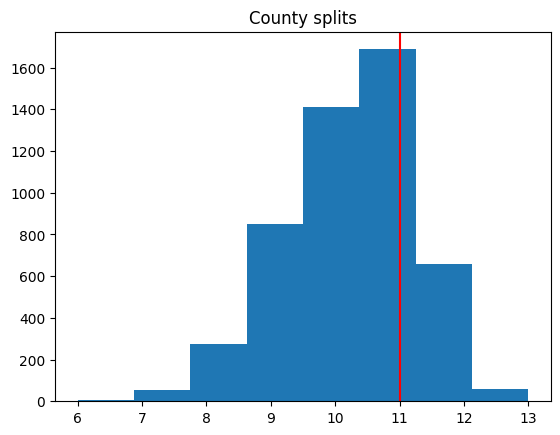

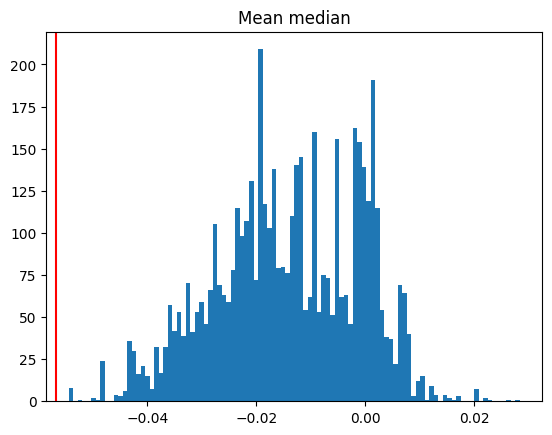

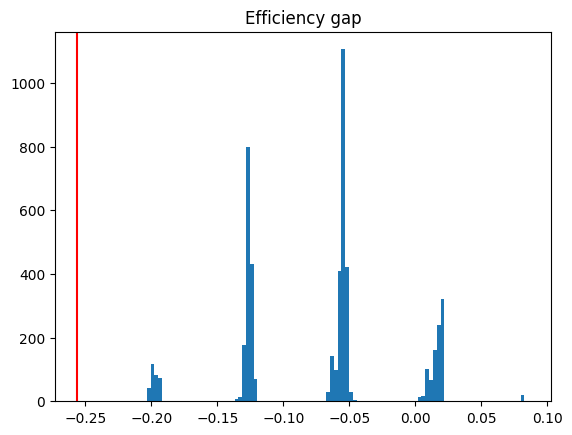

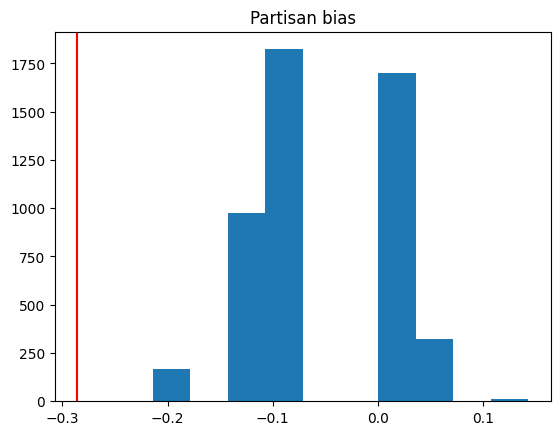

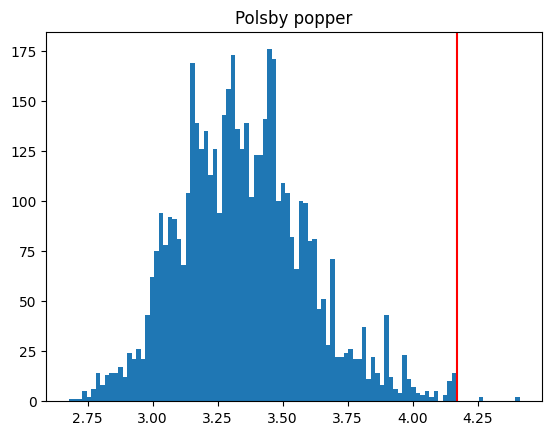

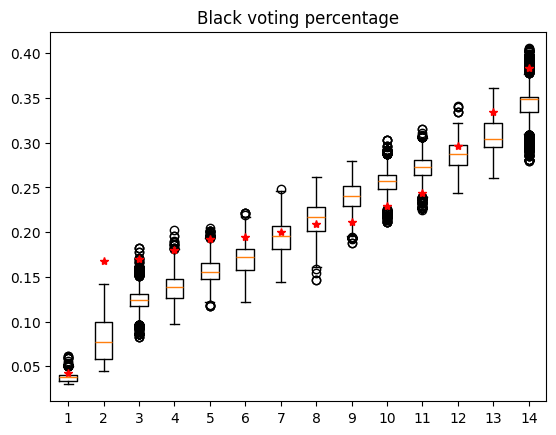

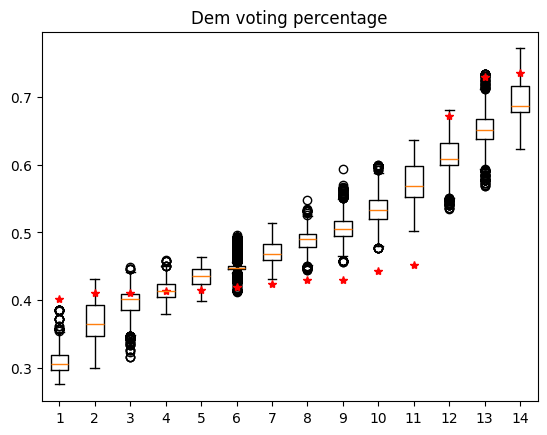

In [63]:
plt.hist(cs, bins=8)
plt.axvline(11, color='red',label='Enacted')
plt.title("County splits")
plt.show()

plt.hist(mms,bins=100)
plt.axvline(-0.05668032542711077, color='red',label='Enacted')
plt.title("Mean median")
plt.show()

plt.hist(egs,bins=100)
plt.axvline(-0.25611450640053, color='red',label='Enacted')
plt.title("Efficiency gap")
plt.show()

plt.hist(pbs)
plt.axvline(-0.2857142857142857, color='red',label='Enacted')
plt.title("Partisan bias")
plt.show()

plt.hist(pps,bins=100)
plt.axvline(4.17002956008203, color='red',label='Enacted')
plt.title("Polsby popper")
plt.show()

bvp = np.array(bvp)
plt.boxplot(bvp)
plt.plot(range(1,15),sorted([0.22942044041576282,
 0.19229480241029692,
 0.17956793200417584,
 0.04239387124357679,
 0.3343947666604468,
 0.2090103932041959,
 0.16776705580854165,
 0.20011859792092224,
 0.19469551364130155,
 0.1695334362636302,
 0.2111577988153698,
 0.29668742389424085,
 0.38389802664664036,
 0.24333683400032827]), "*", color='red',label='NH_Black')
plt.title("Black voting percentage")
plt.show()

dvp = np.array(dvp)
plt.boxplot(dvp)
plt.plot(range(1,15),
         sorted([0.41886754221788536,0.4102550692587003,0.4015134041175902,0.4518196604772827,0.44262948889535925,0.42972030525431776,0.42424257414722344,0.41316756365141794,0.4152301363495878,0.4105112876315188,0.7289525437627258,0.4301783057905161,0.7353109186481949,0.6714747293927874]),"*", color='red',label='Enacted')
plt.title("Dem voting percentage")
plt.show()